# Ranking the merchants

This notebook answers the project's two questions:

1. **What are the 100 best merchants to onboard?** It ranks all 4,026 merchants, overall and within five segments.
2. **What separates merchants that should and shouldn't be accepted?**

**The ranking system in one sentence:** rank merchants by the **profit they are expected to bring the BNPL firm over
the next 12 months**, which is the revenue it would earn from them (`forecast.ipynb`) minus the fraud it would
expect to lose through them (`fraud.ipynb`). A few business rules then remove merchants the firm shouldn't take on.

Outputs, in `output/`:
- `merchant_ranking.csv`: every merchant with its score, rank, segment rank and recommendation
- `top_100_merchants.csv`
- `top_10_per_segment.csv`

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter
from scipy.stats import spearmanr

Settings and helper functions used throughout this notebook: file paths, key dates, chart colours and formatting.

In [2]:
# Files
CURATED = Path("curated")              # files the notebooks pass to each other
OUTPUT = Path("output")                # final rankings (CSV)
PLOTS = Path("plots")                  # charts, saved for the presentation
MERCHANT_DAILY = CURATED / "merchant_daily.parquet"          # from features.ipynb
MERCHANT_FEATURES = CURATED / "merchant_features.parquet"    # from features.ipynb
MERCHANT_FORECAST = CURATED / "merchant_forecast.parquet"    # from forecast.ipynb

# Key dates
LAST_DAY = "2022-10-26"         # last day of the transactions
SECOND_SNAPSHOT = "2021-08-28"  # first day of the second snapshot: the fraud files flag ~6x more from here
COVERAGE_END = "2022-02-27"     # last day either fraud file covers

SEGMENT_ORDER = ["Technology & Media", "Home & Garden", "Fashion & Personal Care", "Hobbies, Arts & Gifts",
                 "Outdoor & Auto"]  # the segments defined in features.ipynb, in a fixed order

# Chart colours
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE = "#2a78d6"            # the main colour
ORANGE = "#eb6834"          # what loses money
CONTEXT_GREY = "#b9b8b2"    # everything that isn't the point of the chart


def apply_style():
    """Quiet, consistent chart defaults (the same palette as etl.ipynb). Also stops Jupyter reading the dollar
    signs in tables as maths formulas."""
    pd.set_option("display.html.use_mathjax", False)
    pd.set_option("styler.html.mathjax", False)
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.titlelocation": "left", "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "axes.axisbelow": True,
        "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_SECONDARY, "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False, "legend.labelcolor": INK, "font.size": 10,
        "lines.linewidth": 2, "lines.solid_capstyle": "round",
    })


def money(x, _=None):
    """$950, $12K, $3.4M (also works as an axis tick formatter)."""
    sign, x = ("-" if x < 0 else ""), abs(x)
    if x >= 1e6:
        return f"{sign}${x / 1e6:,.1f}M".replace(".0M", "M")
    if x >= 1e3:
        return f"{sign}${x / 1e3:,.0f}K"
    return f"{sign}${x:,.0f}"


def show_markdown(text):
    """Display Markdown text. Jupyter reads anything between two dollar signs ("$5 ... $10") as a maths formula, so
    each dollar sign is escaped and wrapped in its own <span> (the markdown cells do the same)."""
    text = re.sub(r"\$(\d(?:[\d,]*\d)?(?:\.\d+)?[KMB]?)", r"<span>\\$\1</span>", text)
    text = re.sub(r"(?<!\\)\$", r"<span>\\$</span>", text)
    display(Markdown(text))


def save(fig, name):
    """Save a chart to plots/ for the presentation slides."""
    PLOTS.mkdir(exist_ok=True)
    fig.savefig(PLOTS / f"{name}.png", dpi=150, bbox_inches="tight")

In [3]:
apply_style()
OUTPUT.mkdir(exist_ok=True)

features = pd.read_parquet(MERCHANT_FEATURES).set_index("merchant_abn")
forecast = pd.read_parquet(MERCHANT_FORECAST).set_index("merchant_abn")
merchants = features.join(forecast.drop(columns=["transactions_12m"]), validate="one_to_one")
print(f"{len(merchants):,} merchants")

4,026 merchants


## 1. The score: expected profit over the next 12 months

For each dollar of a merchant's sales, the BNPL firm:
- **earns the take rate** $t$ if the sale is genuine, which happens with probability $(1 - f)$;
- **loses the dollar** (less the take rate it never collects) if the sale is fraudulent, which happens with
  probability $f$. The firm has paid the merchant and is never repaid.

$$\text{expected profit} = \text{forecast sales} \times \big[\, t\,(1-f) \;-\; \lambda\, f\,(1-t) \,\big]$$

where $f$ is the merchant's forecast fraud rate and $\lambda$ is the share of a fraudulent sale the firm loses.
The main ranking assumes **$\lambda = 1$**: the firm carries the whole loss, as BNPL providers usually do, since
that protection is part of what they sell to merchants. Then the formula simplifies to
$\text{forecast sales} \times (t - f)$. **A merchant is only worth onboarding if its take rate is above its fraud
rate.** Section 6 checks how much the ranking depends on $\lambda$.

Example: two merchants that each sell **<span>\$1M</span>** next year at a **5%** take rate earn the firm **<span>\$50,000</span>** each. If one
is a florist with 0.15% expected fraud, it is worth about **<span>\$48,500</span>**. If the other is a jeweller with 30% expected
fraud, it is worth about **-<span>\$250,000</span>**.

In [4]:
FRAUD_LOSS_SHARE = 1.0  # lambda: share of a fraudulent sale the BNPL firm loses


def expected_profit(data, loss_share=FRAUD_LOSS_SHARE, fraud_rate=None):
    t = data["take_rate"] / 100
    f = data["forecast_fraud_rate"] if fraud_rate is None else fraud_rate
    return data["forecast_sales_12m"] * (t * (1 - f) - loss_share * f * (1 - t))


merchants["expected_profit_12m"] = expected_profit(merchants)
# share of the revenue that expected fraud takes back (above 100% the merchant loses money)
merchants["fraud_to_revenue"] = merchants["forecast_fraud_rate"] / (merchants["take_rate"] / 100)

## 2. Business rules

Some merchants shouldn't be onboarded whatever their score. They are kept in the ranking file, below every eligible
merchant, with the reason:

| Rule | Why |
|---|---|
| **Expected profit must be positive** | the firm would lose money on the partnership |
| **A sale in the last 90 days** | a merchant that has gone quiet may have closed or stopped trading |
| **No day rated 50%+ in the merchant fraud file** | the firm's own fraud checks rated the merchant more likely fraudulent than not |

In [5]:
INACTIVE_DAYS = 90
MERCHANT_FRAUD_LIMIT = 0.5

reasons = pd.DataFrame({
    "loses money": merchants["expected_profit_12m"] <= 0,
    f"no sale in {INACTIVE_DAYS}+ days": merchants["days_since_last"] >= INACTIVE_DAYS,
    "merchant fraud flag": merchants["max_merchant_fraud_probability"].fillna(0) >= MERCHANT_FRAUD_LIMIT,
})
merchants["not_recommended_because"] = reasons.apply(lambda row: ", ".join(row.index[row]), axis=1)
merchants["eligible"] = merchants["not_recommended_because"] == ""

rule_counts = pd.DataFrame({"merchants failing the rule": reasons.sum(),
                            "...and failing only this rule": reasons[reasons.sum(axis=1) == 1].sum()})
display(rule_counts)
print(f"{merchants['eligible'].sum():,} of {len(merchants):,} merchants pass every rule")

,merchants failing the rule,...and failing only this rule
loses money,745,677
no sale in 90+ days,65,5
merchant fraud flag,16,8


3,268 of 4,026 merchants pass every rule


The profit rule removes the most merchants by far, almost all of them big-ticket sellers. The 90-day rule mostly
catches small merchants that were already loss-making. The merchant-fraud rule catches a handful of small merchants.

## 3. The ranking

Eligible merchants are ranked by expected profit. Merchants that fail a rule follow them, also ordered by profit, so
**every merchant has a rank**. Each merchant also gets a rank within its segment (section 5).

In [6]:
merchants = merchants.sort_values(["eligible", "expected_profit_12m"], ascending=[False, False])
merchants["rank"] = np.arange(1, len(merchants) + 1)
merchants["segment_rank"] = merchants.groupby("segment").cumcount() + 1
merchants["recommendation"] = np.select(
    [merchants["eligible"] & (merchants["rank"] <= 100), merchants["eligible"]],
    ["top 100", "eligible"], default="not recommended")

top_100 = merchants[merchants["recommendation"] == "top 100"]
SHOW = {"merchant_name": "merchant", "segment": "segment", "category_label": "category", "take_rate": "take rate (%)",
        "forecast_revenue_12m": "forecast revenue", "forecast_fraud_rate": "expected fraud (% of sales)",
        "expected_profit_12m": "expected profit", "confidence": "confidence"}
FORMATS = {"forecast revenue": money, "expected profit": money, "expected fraud (% of sales)": "{:.2%}",
           "take rate (%)": "{:.2f}"}


def show(table, rows=None):
    shown = table.reset_index().set_index("rank")[list(SHOW)].rename(columns=SHOW)
    return shown.head(rows).style.format(FORMATS) if rows else shown.style.format(FORMATS)


display(show(top_100))

,merchant,segment,category,take rate (%),forecast revenue,expected fraud (% of sales),expected profit,confidence
rank,,,,,,,,
1,Orci In Consequat Corporation,"Hobbies, Arts & Gifts",Gifts & souvenirs,6.61,$481K,0.13%,$471K,high
2,Leo In Consulting,Fashion & Personal Care,Watch & jewellery repair,6.43,$469K,0.11%,$461K,high
3,Lacus Consulting,"Hobbies, Arts & Gifts",Gifts & souvenirs,6.98,$433K,0.11%,$426K,high
4,Lobortis Ultrices Company,"Hobbies, Arts & Gifts",Music shops,6.31,$434K,0.12%,$426K,high
5,Ornare Limited,Outdoor & Auto,Motor vehicle parts,5.91,$450K,0.34%,$424K,high
6,Mauris Non Institute,Technology & Media,Pay TV & radio,6.10,$439K,0.30%,$418K,high
7,Dignissim Maecenas Foundation,Fashion & Personal Care,Opticians,6.64,$461K,0.65%,$416K,high
8,Est Nunc Consulting,Outdoor & Auto,Tents & awnings,6.01,$414K,0.12%,$405K,high
9,Odio Phasellus Institute,"Hobbies, Arts & Gifts",Artist supply & craft,6.59,$439K,0.78%,$387K,high


In [7]:
total_profit = merchants.loc[merchants["expected_profit_12m"] > 0, "expected_profit_12m"].sum()
top_100_profit = top_100["expected_profit_12m"].sum()
print(f"The top 100 are expected to bring {money(top_100_profit)} of profit over the next 12 months: "
      f"{top_100_profit / total_profit:.0%} of the profit available from every profitable merchant "
      f"({money(total_profit)}), from {100 / len(merchants):.1%} of the merchants.")
print(f"Forecast confidence of the top 100: {top_100['confidence'].value_counts().to_dict()}")

The top 100 are expected to bring $20.9M of profit over the next 12 months: 37% of the profit available from every profitable merchant ($56.1M), from 2.5% of the merchants.
Forecast confidence of the top 100: {'high': 100}


## 4. What separates merchants that should and shouldn't be accepted

Expected profit has three parts: **how much a merchant sells**, **its take rate** and **its fraud rate**. The chart
shows every merchant on the two dimensions that matter: what it would earn the firm, and how much of that
fraud would take back.

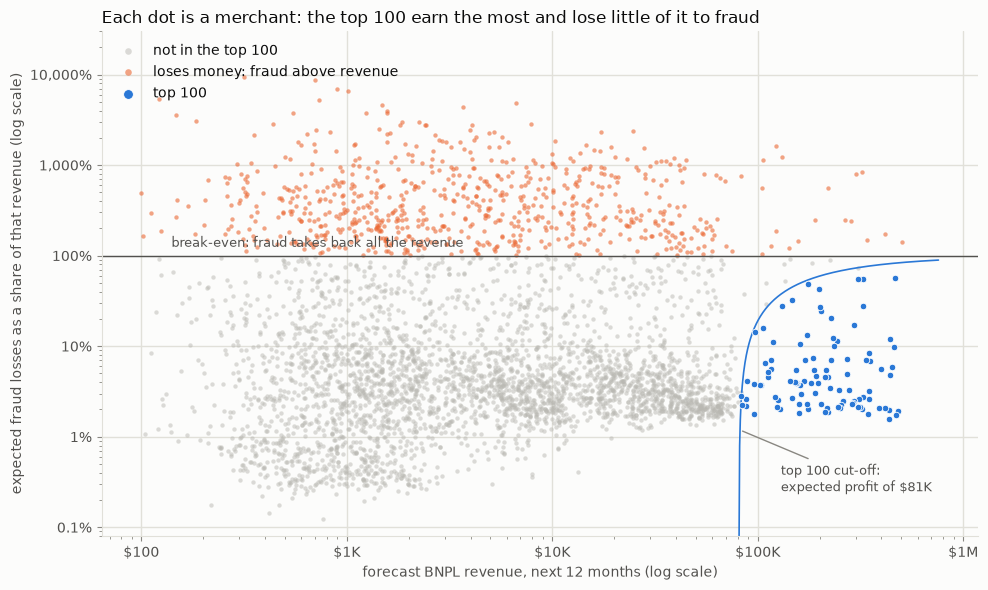

In [8]:
cutoff = top_100["expected_profit_12m"].min()
plot = merchants[merchants["forecast_revenue_12m"] > 100].copy()
plot["y"] = plot["fraud_to_revenue"].clip(lower=1e-3, upper=200)
groups = [("not in the top 100", ~plot["recommendation"].eq("top 100") & (plot["fraud_to_revenue"] <= 1), CONTEXT_GREY, 10, 0.5),
          ("loses money: fraud above revenue", plot["fraud_to_revenue"] > 1, ORANGE, 10, 0.6),
          ("top 100", plot["recommendation"].eq("top 100"), BLUE, 22, 1.0)]

fig, ax = plt.subplots(figsize=(10, 6))
for label, mask, color, size, alpha in groups:
    ax.scatter(plot.loc[mask, "forecast_revenue_12m"], plot.loc[mask, "y"], s=size, color=color, alpha=alpha,
               linewidth=0.6 if label == "top 100" else 0, edgecolor="white", label=label, zorder=3 if label == "top 100" else 2)
ax.axhline(1, color=INK_SECONDARY, linewidth=1)
ax.text(140, 1.25, "break-even: fraud takes back all the revenue", color=INK_SECONDARY, fontsize=9)
revenue_line = np.geomspace(cutoff * 1.0005, plot["forecast_revenue_12m"].max() * 1.5, 300)
ax.plot(revenue_line, 1 - cutoff / revenue_line, color=BLUE, linewidth=1.2)
ax.annotate(f"top 100 cut-off:\nexpected profit of {money(cutoff)}", xy=(cutoff * 1.012, 1 - 1 / 1.012),
            xytext=(cutoff * 1.6, 0.0025), color=INK_SECONDARY, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(8e-4, 300)
ax.xaxis.set_major_formatter(FuncFormatter(money))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{100 * y:,.{1 if y < 0.01 else 0}f}%"))
ax.set_xlabel("forecast BNPL revenue, next 12 months (log scale)")
ax.set_ylabel("expected fraud losses as a share of that revenue (log scale)")
ax.legend(loc="upper left", markerscale=1.5)
ax.set_title("Each dot is a merchant: the top 100 earn the most and lose little of it to fraud", fontsize=12)
fig.tight_layout()
save(fig, "ranking_map")
plt.show()

- **Below the black line**, fraud takes back less than the merchant earns the firm. **Above it** (orange), the
  merchant loses money, however large its sales.
- **The blue curve** is the top-100 cut-off. Every merchant to its right and below it is expected to earn more than
  the 100th merchant. Because the curve bends, a merchant with more revenue can afford a little more fraud.
- The top 100 sit in the bottom-right corner: **the most revenue, with fraud taking back only a few percent of it**.

The table compares typical (median) values.

In [9]:
profiles = {
    "top 100": merchants["recommendation"].eq("top 100"),
    "other eligible": merchants["recommendation"].eq("eligible"),
    "not recommended": merchants["recommendation"].eq("not recommended"),
}
compare = {
    "merchants": lambda d: len(d),
    "transactions, last 12 months": lambda d: d["transactions_12m"].median(),
    "customers, last 12 months": lambda d: d["customers_12m"].median(),
    "average order ($)": lambda d: d["mean_order"].median(),
    "take rate (%)": lambda d: d["take_rate"].median(),
    "revenue level a / b / c / d / e (%)": lambda d: " / ".join(
        f"{100 * share:.0f}" for share in d["revenue_level"].value_counts(normalize=True).reindex(list("abcde"), fill_value=0)),
    "expected fraud (% of sales)": lambda d: 100 * d["forecast_fraud_rate"].median(),
    "sales growth (%)": lambda d: 100 * d["sales_growth"].median(),
    "repeat customers (%)": lambda d: 100 * d["repeat_customer_share"].median(),
    "customer median income ($)": lambda d: d["customer_median_income"].median(),
}
comparison = pd.DataFrame({group: {name: f(merchants[mask]) for name, f in compare.items()}
                           for group, mask in profiles.items()})
display(comparison.map(lambda v: v if isinstance(v, str) else f"{v:,.2f}" if abs(v) < 10 else f"{v:,.0f}"))

,top 100,other eligible,not recommended
merchants,100,"3,168",758
"transactions, last 12 months","16,266",365,24
"customers, last 12 months","11,798",362,24
average order ($),249,232,"2,617"
take rate (%),5.61,4.69,3.77
revenue level a / b / c / d / e (%),53 / 34 / 13 / 0 / 0,43 / 32 / 21 / 2 / 1,24 / 39 / 30 / 4 / 2
expected fraud (% of sales),0.16,0.14,12
sales growth (%),20,20,20
repeat customers (%),43,1.37,0.00
customer median income ($),"53,723","53,723","53,683"


**Features and heuristics that separate merchants:**

1. **Size is the biggest factor.** The top 100 have a median of about 16,000 transactions in the last year, against a
   few hundred for everyone else. No top-100 merchant has fewer than about 2,200.
2. **Big-ticket merchants are the ones to avoid.** Fraud follows order size (`fraud.ipynb`), and expected fraud
   exceeds the take rate for most merchants with average orders in the thousands. The top 100 all have average
   orders under about <span>\$1,350</span>, while the merchants not recommended have a median average order of about <span>\$2,600</span> and
   a median expected fraud rate of 12% of sales.
3. **Take rate matters, but less than size.** About half of the top 100 are revenue level a (the highest take
   rates), and none are level d or e. A high take rate can't rescue a small or fraud-prone merchant, though.
   Take rates vary about 20-fold between levels, while sales vary more than 1,000-fold.
4. **Growth and customer demographics don't separate merchants.** The three groups have the same median growth
   (20%) and the same customer income. Repeat customers do differ (43% vs about 1%), but only because they track
   size (`features.ipynb`), so they add nothing once size is known.

As a rule of thumb for screening a new applicant: **a high-volume merchant with everyday order values (well under
<span>\$1,000</span>) and a take rate of at least ~1.5%.** Big-ticket merchants (jewellery, antiques, art, telecom, equipment
rental) should only be considered with fraud controls that bring their fraud rate below their take rate.

In [10]:
revenue_only = merchants.nlargest(100, "forecast_revenue_12m")
dropped = revenue_only[~revenue_only.index.isin(top_100.index)]
print(f"Ranking by forecast revenue alone (ignoring fraud) would pick {len(dropped)} merchants that aren't in the top 100. "
      f"{(dropped['expected_profit_12m'] <= 0).sum()} of them are expected to LOSE money:")
display(show(dropped.sort_values("expected_profit_12m")))

Ranking by forecast revenue alone (ignoring fraud) would pick 18 merchants that aren't in the top 100. 12 of them are expected to LOSE money:


,merchant,segment,category,take rate (%),forecast revenue,expected fraud (% of sales),expected profit,confidence
rank,,,,,,,,
4026,Commodo Ipsum Industries,Fashion & Personal Care,Jewellery shops,4.93,$321K,41.41%,-$2.4M,medium
4025,Lacus Aliquam Corporation,"Hobbies, Arts & Gifts",Antiques,4.22,$302K,33.72%,-$2.1M,medium
4023,Ligula Elit Pretium Foundation,"Hobbies, Arts & Gifts",Antiques,4.82,$132K,58.73%,-$1.5M,medium
4021,Pede Cras Vulputate Ltd,Technology & Media,Telecom,3.15,$219K,17.52%,-$997K,high
4014,Semper Auctor PC,Outdoor & Auto,Motor vehicle parts,4.52,$284K,10.98%,-$406K,high
4009,At Pretium Corp.,Outdoor & Auto,Motor vehicle parts,6.95,$266K,17.00%,-$385K,medium
3999,Nec Incorporated,Technology & Media,Telecom,5.55,$416K,9.70%,-$311K,high
3997,Mi Eleifend Associates,Outdoor & Auto,Motor vehicle parts,6.02,$190K,14.79%,-$276K,medium
3985,Amet Risus Inc.,Home & Garden,Furniture,6.82,$505K,9.56%,-$203K,high


Ignoring fraud would be costly: several of the highest-revenue merchants are among the worst for the firm.

## 5. Segments

The 25 categories are grouped into **five segments** by what the customer is buying. This matches how a BNPL firm
would organise its sales teams, and each segment is big enough (at least 400 merchants) for a meaningful top 10:

| Segment | Categories |
|---|---|
| Technology & Media | computers & software, IT services, telecom, pay TV & radio, digital goods |
| Home & Garden | furniture, lawn & garden, florists, equipment rental |
| Fashion & Personal Care | shoes, jewellery shops, watch & jewellery repair, opticians, health & beauty spas |
| Hobbies, Arts & Gifts | artist supply & craft, art dealers, antiques, hobby/toys/games, music shops, gifts & souvenirs, books & newspapers, stationery |
| Outdoor & Auto | tents & awnings, bicycle shops, motor vehicle parts |

In [11]:
segment_profile = merchants.groupby("segment").agg(
    merchants=("merchant_name", "size"),
    forecast_revenue=("forecast_revenue_12m", "sum"),
    expected_profit=("expected_profit_12m", lambda p: p[p > 0].sum()),
    median_order=("mean_order", "median"),
    loses_money=("expected_profit_12m", lambda p: (p <= 0).mean()),
    in_top_100=("recommendation", lambda r: (r == "top 100").sum()),
).reindex(SEGMENT_ORDER)
segment_profile["share_of_merchants"] = segment_profile["merchants"] / len(merchants)
segment_profile["share_of_top_100"] = segment_profile["in_top_100"] / 100
display(segment_profile.style.format({"forecast_revenue": money, "expected_profit": money, "median_order": "${:,.0f}",
                                      "loses_money": "{:.0%}", "share_of_merchants": "{:.0%}", "share_of_top_100": "{:.0%}"}))

loss_by_category = (merchants.groupby(["segment", "category_label"])["expected_profit_12m"]
                    .agg(merchants="size", loses_money=lambda p: (p <= 0).mean()).reset_index())
display(loss_by_category[loss_by_category["loses_money"] >= 0.25].sort_values(["segment", "loses_money"], ascending=[True, False])
        .style.format({"loses_money": "{:.0%}"}).hide(axis="index"))

,merchants,forecast_revenue,expected_profit,median_order,loses_money,in_top_100,share_of_merchants,share_of_top_100
segment,,,,,,,,
Technology & Media,867,$15.2M,$12.9M,$156,14%,18,22%,18%
Home & Garden,649,$11.9M,$7.8M,$331,31%,17,16%,17%
Fashion & Personal Care,761,$11.9M,$10.2M,$206,12%,17,19%,17%
"Hobbies, Arts & Gifts",1250,$22.5M,$17.4M,$488,21%,33,31%,33%
Outdoor & Auto,499,$11.9M,$7.9M,$486,14%,15,12%,15%


segment,category_label,merchants,loses_money
Fashion & Personal Care,Jewellery shops,91,99%
"Hobbies, Arts & Gifts",Art dealers,112,95%
"Hobbies, Arts & Gifts",Antiques,129,68%
"Hobbies, Arts & Gifts","Hobby, toys & games",142,37%
Home & Garden,Equipment rental,134,89%
Home & Garden,Furniture,182,28%
Outdoor & Auto,Motor vehicle parts,151,28%
Technology & Media,Telecom,125,95%


**The same score is used in every segment.** Profit is comparable across segments, and the firm's onboarding
capacity is shared, so a common yardstick lets a segment's top 10 be compared directly with the overall top 100.
What does differ by segment is **what decides the ranking**:

- **Four segments contain a big-ticket category where almost every merchant loses money:** jewellery shops (Fashion &
  Personal Care), art dealers and antiques (Hobbies, Arts & Gifts), equipment rental (Home & Garden) and telecom
  (Technology & Media). In these segments, fraud decides who is excluded, and size and take rate then decide the
  order among the rest.
- **Outdoor & Auto** has no category that is mostly loss-making. Its riskiest category is motor vehicle parts (28% of
  merchants lose money), so the ranking there is mostly about size and take rate.
- **Home & Garden has the highest share of loss-making merchants** (31%, from equipment rental and furniture), but
  its best merchants (furniture shops and florists with everyday order values) still make the top 100.

The top 100 is spread across all five segments, roughly in proportion to their size, so the firm doesn't need a
quota to stay diversified.

In [12]:
top_10 = merchants[merchants["eligible"]].groupby("segment", sort=False).head(10)
SEGMENT_SHOW = {"rank": "overall rank", **{k: v for k, v in SHOW.items() if k != "segment"}}
for segment in SEGMENT_ORDER:
    show_markdown(f"#### {segment}")
    table = top_10[top_10["segment"] == segment].reset_index().set_index("segment_rank")
    table.index.name = "segment rank"
    display(table[list(SEGMENT_SHOW)].rename(columns=SEGMENT_SHOW).style.format(FORMATS))

#### Technology & Media

,overall rank,merchant,category,take rate (%),forecast revenue,expected fraud (% of sales),expected profit,confidence
segment rank,,,,,,,,
1,6,Mauris Non Institute,Pay TV & radio,6.10,$439K,0.30%,$418K,high
2,13,Nullam Consulting,Digital goods,6.33,$345K,0.11%,$339K,high
3,15,Arcu Sed Eu Incorporated,IT services,4.80,$351K,0.33%,$327K,high
4,18,Adipiscing Elit Foundation,Computers & software,5.82,$326K,0.16%,$317K,high
5,22,Diam At Foundation,IT services,6.01,$308K,0.13%,$301K,high
6,25,Eu Placerat LLC,Computers & software,6.16,$287K,0.14%,$280K,high
7,29,Suspendisse Ac Associates,Digital goods,4.70,$260K,0.12%,$253K,high
8,30,Eleifend PC,IT services,5.97,$254K,0.13%,$249K,high
9,39,Nullam Enim Ltd,Computers & software,3.22,$228K,0.23%,$212K,high


#### Home & Garden

,overall rank,merchant,category,take rate (%),forecast revenue,expected fraud (% of sales),expected profit,confidence
segment rank,,,,,,,,
1,19,Phasellus At Limited,Furniture,4.65,$335K,0.33%,$311K,high
2,21,Lorem Ipsum Sodales Industries,Florists,4.47,$312K,0.12%,$304K,high
3,26,Auctor Company,Florists,4.50,$279K,0.15%,$270K,high
4,31,Purus Gravida Sagittis Ltd,Florists,6.63,$250K,0.14%,$245K,high
5,33,Eu Inc.,Lawn & garden,5.97,$247K,0.13%,$241K,high
6,40,Semper Corp.,Florists,5.93,$216K,0.12%,$212K,high
7,42,Interdum Feugiat Sed Inc.,Furniture,3.24,$221K,0.15%,$210K,high
8,49,Erat Vitae LLP,Florists,2.94,$196K,0.12%,$188K,high
9,53,Phasellus Dapibus Incorporated,Furniture,2.68,$187K,0.15%,$177K,high


#### Fashion & Personal Care

,overall rank,merchant,category,take rate (%),forecast revenue,expected fraud (% of sales),expected profit,confidence
segment rank,,,,,,,,
1,2,Leo In Consulting,Watch & jewellery repair,6.43,$469K,0.11%,$461K,high
2,7,Dignissim Maecenas Foundation,Opticians,6.64,$461K,0.65%,$416K,high
3,10,Gravida Mauris Incorporated,Watch & jewellery repair,6.35,$389K,0.13%,$381K,high
4,46,Dolor Quisque Inc.,Shoe shops,3.41,$231K,0.42%,$203K,high
5,48,Blandit At LLC,Shoe shops,5.71,$204K,0.13%,$199K,high
6,50,At Pede Inc.,Opticians,6.15,$190K,0.19%,$184K,high
7,56,Sociosqu Corp.,Shoe shops,6.57,$175K,0.13%,$172K,high
8,57,Hendrerit A Corporation,Watch & jewellery repair,6.64,$174K,0.15%,$170K,high
9,61,Nulla Facilisis Institute,Watch & jewellery repair,6.82,$158K,0.12%,$155K,high


#### Hobbies, Arts & Gifts

,overall rank,merchant,category,take rate (%),forecast revenue,expected fraud (% of sales),expected profit,confidence
segment rank,,,,,,,,
1,1,Orci In Consequat Corporation,Gifts & souvenirs,6.61,$481K,0.13%,$471K,high
2,3,Lacus Consulting,Gifts & souvenirs,6.98,$433K,0.11%,$426K,high
3,4,Lobortis Ultrices Company,Music shops,6.31,$434K,0.12%,$426K,high
4,9,Odio Phasellus Institute,Artist supply & craft,6.59,$439K,0.78%,$387K,high
5,11,Dictum Phasellus In Institute,Gifts & souvenirs,5.65,$397K,0.31%,$375K,high
6,12,Phasellus At Company,Gifts & souvenirs,4.95,$348K,0.13%,$339K,high
7,14,Magna Malesuada Corp.,Artist supply & craft,5.56,$348K,0.18%,$337K,high
8,16,Elit Sed Consequat Associates,Artist supply & craft,5.89,$349K,0.49%,$320K,high
9,20,Ornare Fusce Inc.,"Hobby, toys & games",5.98,$315K,0.13%,$309K,high


#### Outdoor & Auto

,overall rank,merchant,category,take rate (%),forecast revenue,expected fraud (% of sales),expected profit,confidence
segment rank,,,,,,,,
1,5,Ornare Limited,Motor vehicle parts,5.91,$450K,0.34%,$424K,high
2,8,Est Nunc Consulting,Tents & awnings,6.01,$414K,0.12%,$405K,high
3,17,Non Vestibulum Industries,Tents & awnings,5.80,$323K,0.12%,$317K,high
4,24,Magna Praesent PC,Motor vehicle parts,6.78,$290K,0.16%,$283K,high
5,32,Luctus Et Incorporated,Tents & awnings,5.69,$295K,0.97%,$245K,high
6,44,Etiam Bibendum Industries,Tents & awnings,6.31,$468K,3.56%,$204K,high
7,47,Suspendisse Non Leo PC,Motor vehicle parts,3.10,$212K,0.14%,$202K,high
8,54,Sit Amet PC,Motor vehicle parts,3.60,$181K,0.14%,$174K,high
9,58,Pede Nonummy Corp.,Tents & awnings,2.86,$168K,0.12%,$161K,high


## 6. How robust is the ranking?

The ranking rests on assumptions. Each one is changed below to see how many of the top 100 would change.

In [13]:
daily = pd.read_parquet(MERCHANT_DAILY)
daily["order_datetime"] = pd.to_datetime(daily["order_datetime"])


def fraud_rate_between(first, last):
    rows = daily[daily["order_datetime"].between(first, last)].groupby("merchant_abn")[["expected_fraud", "sales"]].sum()
    return (rows["expected_fraud"] / rows["sales"]).reindex(merchants.index).fillna(merchants["forecast_fraud_rate"])


variants = {
    "the firm loses half a fraudulent sale (λ = 0.5)": expected_profit(merchants, loss_share=0.5),
    "fraud only costs the take rate (λ = 0)": expected_profit(merchants, loss_share=0),
    "fraud ignored (rank by revenue)": merchants["forecast_revenue_12m"],
    "fraud rate from the fraud files only (no model)": expected_profit(
        merchants, fraud_rate=fraud_rate_between(SECOND_SNAPSHOT, COVERAGE_END)),
    "fraud rate including the under-flagged first snapshot": expected_profit(
        merchants, fraud_rate=fraud_rate_between("2021-02-28", LAST_DAY)),
    "past revenue instead of the forecast": merchants["revenue_12m"] * (
        1 - merchants["fraud_to_revenue"]),
}
# each variant applies the same business rules, with "loses money" judged by its own score
passes_other_rules = merchants["not_recommended_because"].str.replace("loses money", "").str.strip(", ") == ""


def variant_top_100(score):
    return set(score[passes_other_rules & (score > 0)].nlargest(100).index)


robustness = pd.DataFrame({
    name: {
        "top 100 unchanged": len(variant_top_100(score) & set(top_100.index)),
        "rank correlation with the main ranking": spearmanr(score, merchants["expected_profit_12m"]).statistic,
    }
    for name, score in variants.items()
}).T
display(robustness.style.format({"top 100 unchanged": "{:.0f}", "rank correlation with the main ranking": "{:.3f}"}))
robustness.rename_axis("variant").to_csv(OUTPUT / "ranking_robustness.csv")

,top 100 unchanged,rank correlation with the main ranking
the firm loses half a fraudulent sale (λ = 0.5),94,0.951
fraud only costs the take rate (λ = 0),83,0.698
fraud ignored (rank by revenue),82,0.666
fraud rate from the fraud files only (no model),97,0.992
fraud rate including the under-flagged first snapshot,98,0.986
past revenue instead of the forecast,100,1.000


- **Modelling choices barely matter.** Using the past instead of the forecast, or the fraud files instead of the
  model, changes only a handful of the top 100.
- **What the firm assumes about fraud matters most.** If merchants carried half the loss, a few big-ticket merchants
  would move up. If fraud only cost the take rate, or were ignored, the list would change much more, and it would
  include merchants that lose the firm money under the main assumption. **The firm should confirm who carries
  fraud losses before finalising the list.**

In [14]:
columns = ["rank", "merchant_abn", "merchant_name", "segment", "segment_rank", "category", "category_label",
           "revenue_level", "take_rate",
           "forecast_sales_12m", "forecast_revenue_12m", "forecast_fraud_rate", "forecast_fraud_12m",
           "expected_profit_12m", "confidence", "recommendation", "not_recommended_because", "transactions_12m",
           "customers_12m", "mean_order", "first_transaction", "limited_history", "days_since_last",
           "max_merchant_fraud_probability"]
modelling = robustness["top 100 unchanged"].iloc[3:]  # the three modelling variants
ranking = merchants.reset_index()[columns]
ranking.to_csv(OUTPUT / "merchant_ranking.csv", index=False)
ranking[ranking["recommendation"] == "top 100"].to_csv(OUTPUT / "top_100_merchants.csv", index=False)
(ranking[ranking["merchant_abn"].isin(top_10.index)].sort_values(["segment", "segment_rank"])
 .to_csv(OUTPUT / "top_10_per_segment.csv", index=False))
print("saved:", ", ".join(str(OUTPUT / name) for name in ["merchant_ranking.csv", "top_100_merchants.csv",
                                                          "top_10_per_segment.csv"]))

show_markdown(f"""
### Summary

- **Ranking system:** expected profit to the BNPL firm over the next 12 months = forecast sales x (take rate - fraud
  rate), after business rules that remove loss-making, inactive and fraud-flagged merchants
  ({(~merchants['eligible']).sum():,} of {len(merchants):,}).
- **Top 100:** expected to bring **{money(top_100_profit)}** of profit next year, **{top_100_profit / total_profit:.0%}**
  of what all profitable merchants offer. They are spread across all five segments
  ({", ".join(f"{segment} {count}" for segment, count in segment_profile["in_top_100"].items())}).
- **What separates merchants:** size first, then fraud (big-ticket merchants lose more to fraud than they earn), then
  take rate. Growth, repeat customers and customer demographics don't separate merchants in this data.
- **Robustness:** the top 100 hardly depends on the modelling choices
  ({modelling.min():.0f}-{modelling.max():.0f} of 100 unchanged), but it does depend on who carries fraud losses
  ({robustness['top 100 unchanged'].iloc[1]:.0f} unchanged if fraud only cost the take rate).
""")

saved: output/merchant_ranking.csv, output/top_100_merchants.csv, output/top_10_per_segment.csv



### Summary

- **Ranking system:** expected profit to the BNPL firm over the next 12 months = forecast sales x (take rate - fraud
  rate), after business rules that remove loss-making, inactive and fraud-flagged merchants
  (758 of 4,026).
- **Top 100:** expected to bring **<span>\$20.9M</span>** of profit next year, **37%**
  of what all profitable merchants offer. They are spread across all five segments
  (Technology & Media 18, Home & Garden 17, Fashion & Personal Care 17, Hobbies, Arts & Gifts 33, Outdoor & Auto 15).
- **What separates merchants:** size first, then fraud (big-ticket merchants lose more to fraud than they earn), then
  take rate. Growth, repeat customers and customer demographics don't separate merchants in this data.
- **Robustness:** the top 100 hardly depends on the modelling choices
  (97-100 of 100 unchanged), but it does depend on who carries fraud losses
  (83 unchanged if fraud only cost the take rate).
